# DLMI Lecture 01

In this assigment you will work with 3D Slicer and SimpleITK to view images and inspect the image metadata. 

# 3D Slicer

First, start 3D Slicer. In the terminal enter:  
`module load Slicer3D`  
`Slicer`

The data directory for this course is located at `/opt/nfsopt/DLMI` for engineering computers, or `${HOME}/classdata` on IDAS. In this lecture we will use the `CTChest.nii.gz` file located in the `lecture01` subdirectory.

Next open the `CTChest.nii.gz` image. There are 3 ways to open an image in Slicer: 1) Open a file browser, navigate the file system to your file, and drag the file onto the Slicer window, 2) select the `Add data` menubar icon and browse for the file, 3) or select `File -> Add Data` and browse for the file.

Add data: 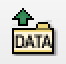

A window will pop up titled "Add data into the scene".  Select the checkbox for "Show Options".  Then ensure the following options:
    Description: Volume
    Labelmap: No
    Single File: Yes
    Centered: No
    Ignore Orientation: No
    Show: Yes
    Colormap: Grey

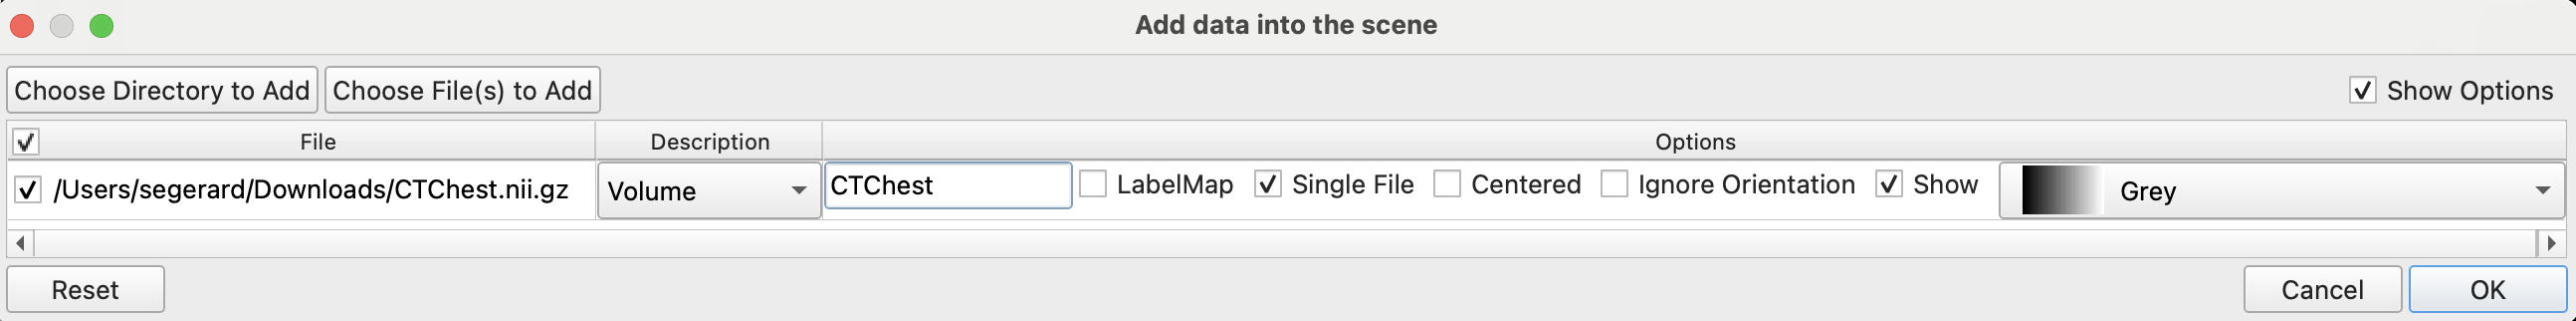

Now, change the viewing layout by selecting `View -> Layout -> Four-Up`.  There is also a menubar icon for changing the layout:

<div>Red slice: 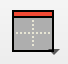</div>
<div>Four-up: 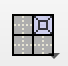</div>

In the top left corner of the Red slice, select the thumbtack icon to view display options:
<div>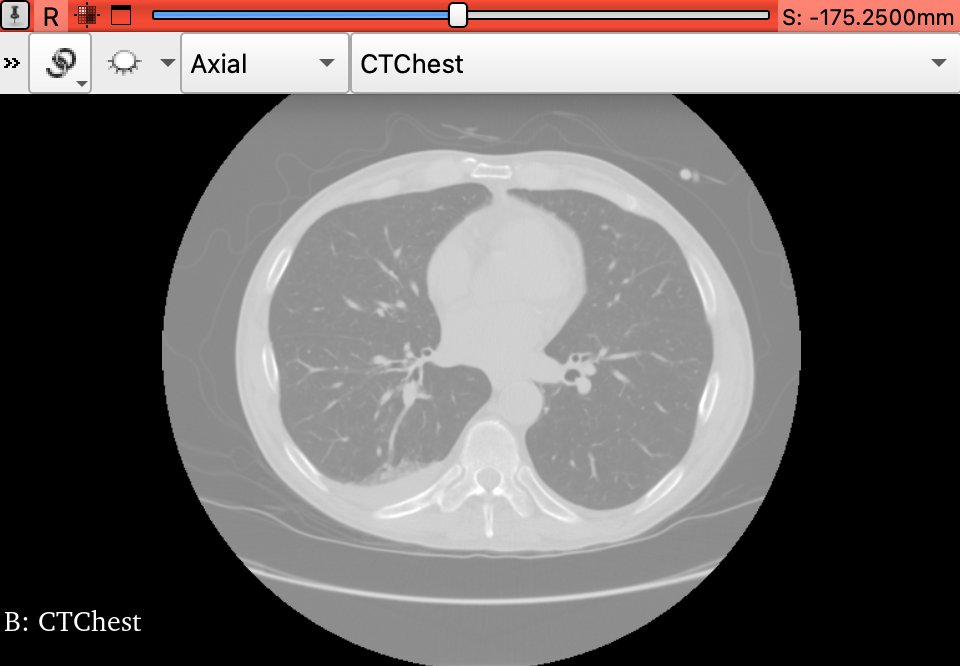</div>

Click on the link icon to link display options across all slice views:

Not linked: 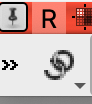
Linked: 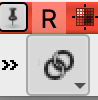

Then select the `<<` button to drop down additional options:
<div>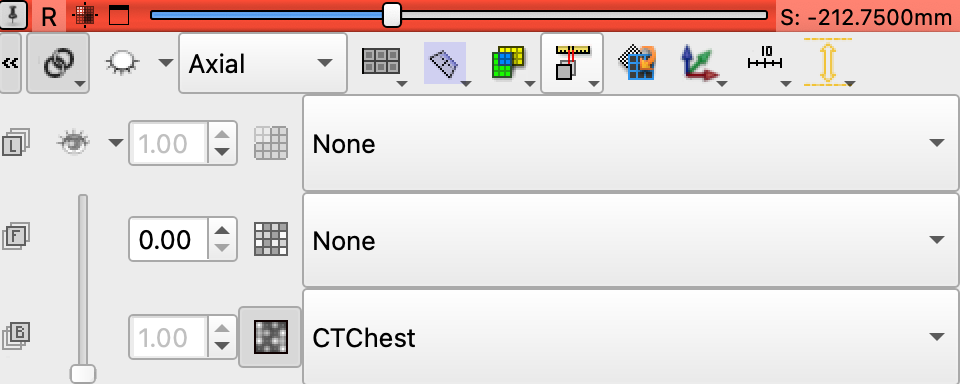</div>

Then click on the image grid icon next to the file name to toggle off interpolation between voxels.

Interpolation on: 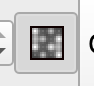
Interpolation off: 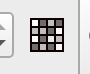

Then click the eye icon to view the Red slice in the 3D view (top right panel of four-up layout).

Display off: 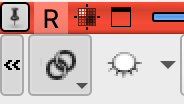
Display on: 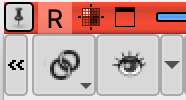

In the `Markdown` cell below, paste a screenshot of your 3D Slicer window. 


**`######################################`  
`####### TODO: paste screenshot #######`  
`######################################`**
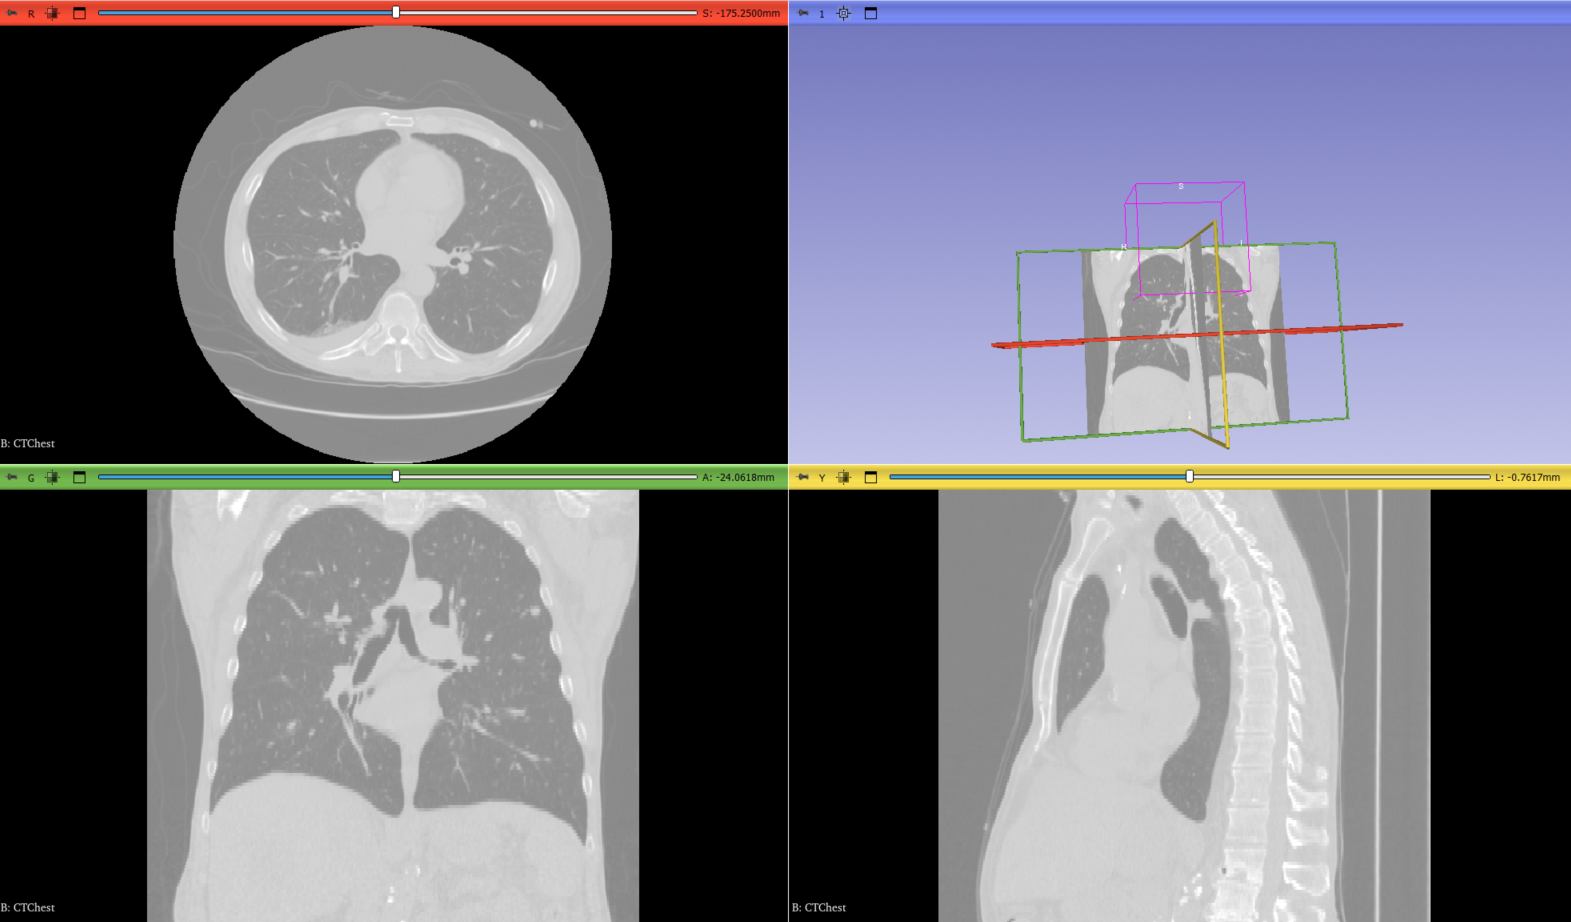

### **QUESTION:**
Hover your mouse over any point on the image. On the bottom left corner (under the data probe section), in the cell below note the voxel index and intensity:

Index (i,j,k): (141, 257, 20) 

Voxel intensity: 27

### **QUESTION:**
Now select the `Volumes` module from the modules dropdown on the menubar, or selecting `View -> Module Finder` and searching.
On the left side of the screen, metadata information about the loaded image is available.
In the cell below, note the image dimensions, spacing, origin, and direction cosine matrix

Image dimensions:  
(512, 512, 139)

Image spacing:  
(0.7617, 0.7617, 2.500)

Image origin:  
(195mm, 171.70mm, -347.75mm) 

Direction cosine matrix:  
-1.00 0.00 0.00
0.00  -1.00 0.00
0.00  0.00 1.000

### **QUESTION:**
Scroll to the `Lookup Table` section of the `Volumes` module.
<div>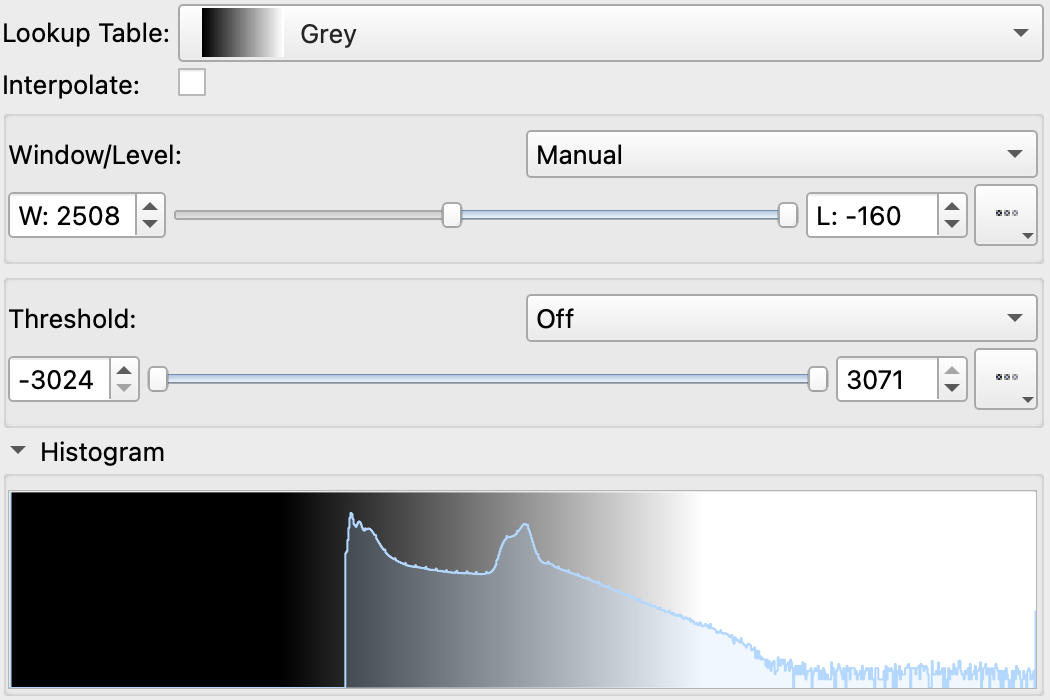</div>

Select the `Histogram` dropdown.
Adjust the `Window/Level` or `Minimum/Maximmum` parameters so that lung voxels are nearly black, soft tissue voxels are grey, and bone voxels are nearly white. In the cell below, note the minimum and maximum display intensities:


### Minimum display intensity: -114 

Maximum display intensity: 3051 

# SimpleITK

Now we will load the same image using a Python package called SimpleITK. Note you will need to update the `fn` variable below to point to the correct path.

In [1]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import os

In [2]:
engr_dir = "/opt/nfsopt/DLMI"
idas_dir = os.path.join(os.path.expanduser('~'), "classdata")

if os.path.isdir(engr_dir):
    data_dir = engr_dir
elif os.path.isdir(idas_dir):  
    data_dir = idas_dir
else:
    print("Data directory not found")
    
fn = os.path.join(data_dir, "lecture01", "CTChest.nii.gz")
im = sitk.ReadImage(fn)

The sitk.Image object has different member functions for accessing metadata including `GetSize()`, `GetSpacing()`, `GetOrigin()`, and `GetDirection()`. For example to get the size/dimension of the image object you could run `im.GetSize()`. Below, print the size, spacing, origin and direction cosine matrix. Compare the values to those identified in Slicer.

Image size/dimension:

In [3]:
######################################
#######         TODO           #######
######################################

im.GetSize()

(512, 512, 139)

Image spacing:

In [4]:
######################################
#######         TODO           #######
######################################
im.GetSpacing()

(0.7617189884185791, 0.7617189884185791, 2.5)

Image origin:

In [5]:
######################################
#######         TODO           #######
######################################
im.GetOrigin()

(-195.0, -171.6999969482422, -347.75)

Direction cosine matrix:

In [5]:
######################################
#######         TODO           #######
######################################
im.GetDirection()

(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Note, the print function is overloaded in the sitk.Image class to print a summary of the metadata:

In [6]:
print(im)

Image (0x560a02858fa0)
  RTTI typeinfo:   itk::Image<int, 3u>
  Reference Count: 1
  Modified Time: 1837
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (none)
  Source output name: (none)
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 1812
  UpdateMTime: 1833
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 139]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 139]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 139]
  Spacing: [0.761719, 0.761719, 2.5]
  Origin: [-195, -171.7, -347.75]
  Direction: 
1 0 0
0 1 0
0 0 1

  IndexToPointMatrix: 
0.761719 0 0
0 0.761719 0
0 0 2.5

  PointToIndexMatrix: 
1.31282 0 0
0 1.31282 0
0 0 0.4

  Inverse Direction: 
1 0 0
0 1 0
0 0 1

  PixelContainer: 
    ImportImageContainer (0x560a02090150)
      RTTI typeinfo:   itk::ImportImageContainer<unsigned long, int>
      Refer

To access the intensity of a voxel you can index into the sitk.Image object using square brackets, e.g., `im[i,j,k]`

Access the voxel intensity value at the index you identified in Slicer and ensure the intensity value is the same

In [7]:
######################################
#######         TODO           #######
######################################

im[141, 257, 20]

27

In the myutils.py file, a function called `myshow` is provided and can be used to display an image in this jupyter notebook. Below we import the function and use `help` to display the docstrings, which shows the function signiture and a description of the inputs/outputs.

In [8]:
from myutils import myshow
help(myshow)

Help on function myshow in module myutils:

myshow(im, slice_index=100, min_intensity=-2000, max_intensity=0)
    Displays an inline image of a slice from a 3D image.
    
    The input image must be 3D.
    
    Inputs:
    - im (sitk.Image): SimpleITK image to display
    - slice_index (int): Index of slice to display
    - min_intensity (int): Minimum display intensity (mapped to black)
    - max_intensity (int): Maximum display intensity (mapped to white)
    
    Returns:



Call the `myshow()` function, specify the same minimum and maximum display intensities identified in Slicer. Also specify which axial slice to display. 

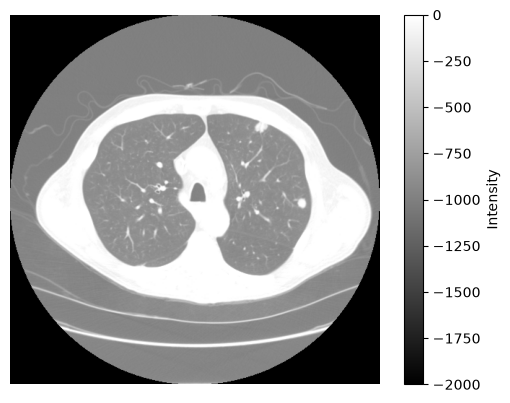

In [10]:
######################################
#######         TODO           #######
######################################
myshow(im)

You can also open 3D Slicer directly from a Jupyter notebook using sitk.ImageViewer:

In [13]:
image_viewer = sitk.ImageViewer()
image_viewer.SetApplication(r'C:\Users\ibeed\AppData\Local\slicer.org\3D Slicer 5.12.3') # Change to 3D slicer path on 1245 computers
image_viewer.Execute(im)

###'/opt/nfsopt/Slicer3D/Slicer-5.6.0-linux-amd64/Slicer'

MetaImageIO (0x560a0293d7b0): Unsupported or empty metaData item ITK_FileNotes of type Ssfound, won't be written to image file

MetaImageIO (0x560a0293d7b0): Unsupported or empty metaData item aux_file of type Ssfound, won't be written to image file

MetaImageIO (0x560a0293d7b0): Unsupported or empty metaData item descrip of type Ssfound, won't be written to image file

MetaImageIO (0x560a0293d7b0): Unsupported or empty metaData item intent_name of type Ssfound, won't be written to image file

MetaImageIO (0x560a0293d7b0): Unsupported or empty metaData item qto_xyz of type N3itk6MatrixIfLj4ELj4EEEfound, won't be written to image file



RuntimeError: Exception thrown in SimpleITK ImageViewer_Execute: /work/src/Code/IO/src/sitkImageViewer.cxx:694:
sitk::ERROR: Error in administrating child process: [No such file or directory].
Command line: 'C:\Users\ibeed\AppData\Local\slicer.org\3D' 'Slicer' '5.12.3' '/tmp/TempFile-165-4.mha' 

On mac, the application path is: `'/Applications/Slicer.app/Contents/MacOS/Slicer'`